In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

In [2]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EPOCHS = 20

TRAIN_DIR = "./train"
VAL_DIR = "./val"
TEST_DIR = "./test"

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

print("Class :", class_names)

Found 771 files belonging to 2 classes.


2026-06-09 10:03:34.425433: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-09 10:03:35.076552: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79135 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:07:00.0, compute capability: 8.0


Found 650 files belonging to 2 classes.
Found 189 files belonging to 2 classes.
Class : ['cock', 'hen']


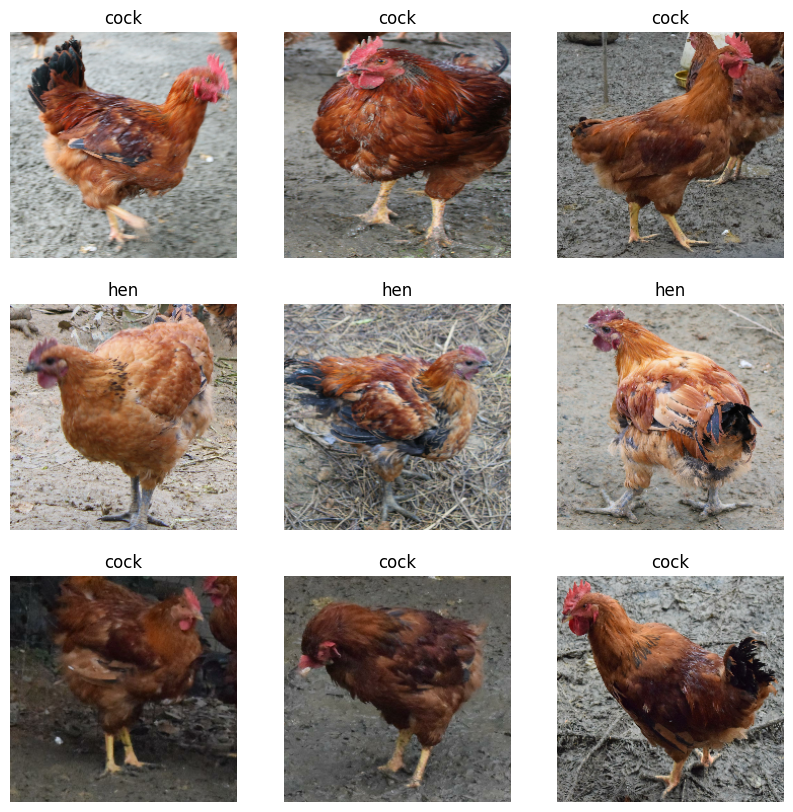

In [6]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")

plt.show()

In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [5]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x)

# GAP
x = GlobalAveragePooling2D()(x)

# Dropout
x = Dropout(0.3)(x)

# Dense + Softmax
outputs = Dense(
    2,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                             

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20


2026-06-09 10:04:39.145687: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8400
2026-06-09 10:04:40.147894: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-09 10:04:40.149023: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-09 10:04:40.149045: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-06-09 10:04:40.150085: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-09 10:04:40.150143: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


 5/25 [=====>........................] - ETA: 0s - loss: 0.6919 - accuracy: 0.5938

2026-06-09 10:04:40.366737: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


25/25 [==============================] - 13s 188ms/step - loss: 0.5001 - accuracy: 0.7613 - val_loss: 0.3275 - val_accuracy: 0.8754
Epoch 2/20
25/25 [==============================] - 4s 138ms/step - loss: 0.3091 - accuracy: 0.8820 - val_loss: 0.2180 - val_accuracy: 0.9615
Epoch 3/20
25/25 [==============================] - 3s 78ms/step - loss: 0.2226 - accuracy: 0.9313 - val_loss: 0.1771 - val_accuracy: 0.9569
Epoch 4/20
25/25 [==============================] - 4s 136ms/step - loss: 0.1914 - accuracy: 0.9339 - val_loss: 0.1492 - val_accuracy: 0.9662
Epoch 5/20
25/25 [==============================] - 4s 94ms/step - loss: 0.1876 - accuracy: 0.9300 - val_loss: 0.1285 - val_accuracy: 0.9862
Epoch 6/20
25/25 [==============================] - 4s 132ms/step - loss: 0.1678 - accuracy: 0.9481 - val_loss: 0.1191 - val_accuracy: 0.9877
Epoch 7/20
25/25 [==============================] - 5s 122ms/step - loss: 0.1636 - accuracy: 0.9429 - val_loss: 0.1055 - val_accuracy: 0.9877
Epoch 8/20
25/25 [

In [12]:
loss, acc = model.evaluate(test_ds)

print(f"Test Accuracy : {acc:.4f}")
print(f"Test Loss     : {loss:.4f}")

6/6 [==============================] - 1s 60ms/step - loss: 0.1083 - accuracy: 0.9683
Test Accuracy : 0.9683
Test Loss     : 0.1083


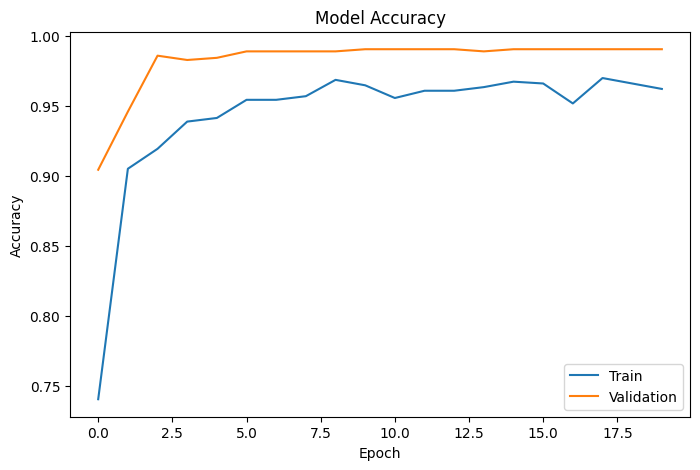

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

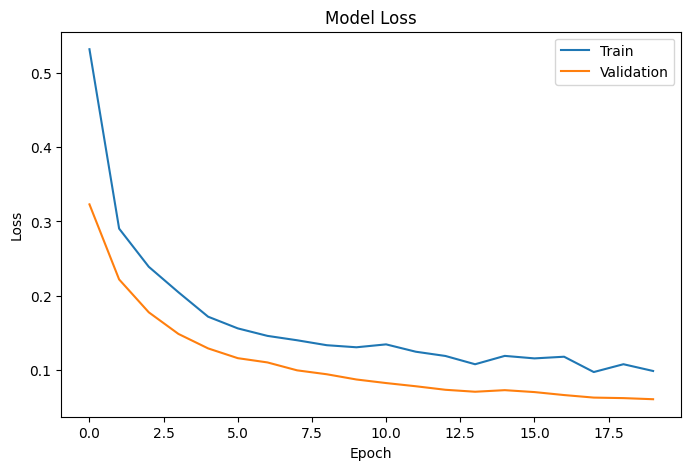

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

In [15]:
model.save(
    "chicken_gender.keras"
)

print("Model saved")

Model saved


In [16]:
converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_model = converter.convert()

with open(
    "chicken_gender.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("TFLite saved")

2026-06-08 16:18:54.154944: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: /tmp/tmpx7rmhepd/assets
TFLite saved


2026-06-08 16:19:32.361737: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:357] Ignored output_format.
2026-06-08 16:19:32.361865: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:360] Ignored drop_control_dependency.
2026-06-08 16:19:32.363079: I tensorflow/cc/saved_model/reader.cc:43] Reading SavedModel from: /tmp/tmpx7rmhepd
2026-06-08 16:19:32.430995: I tensorflow/cc/saved_model/reader.cc:78] Reading meta graph with tags { serve }
2026-06-08 16:19:32.431098: I tensorflow/cc/saved_model/reader.cc:119] Reading SavedModel debug info (if present) from: /tmp/tmpx7rmhepd
2026-06-08 16:19:32.679658: I tensorflow/cc/saved_model/loader.cc:228] Restoring SavedModel bundle.
2026-06-08 16:19:33.320058: I tensorflow/cc/saved_model/loader.cc:212] Running initialization op on SavedModel bundle at path: /tmp/tmpx7rmhepd
2026-06-08 16:19:33.659920: I tensorflow/cc/saved_model/loader.cc:301] SavedModel load for tags { serve }; Status: success: OK. Took 1296844

In [18]:
import os

size_mb = os.path.getsize(
    "chicken_gender.tflite"
) / (1024*1024)

print(
    f"TFLite Size : {size_mb:.2f} MB"
)

TFLite Size : 15.31 MB
